# توقع أسعار السيارات المستعملة في السعودية

مشروع تعلّم آلة لبناء نموذج يتنبأ بسعر السيارة المستعملة (بالريال السعودي) اعتمادًا على خصائصها (الماركة، السنة، المسافة المقطوعة، سعة المحرك، الحالة، وغيرها)، بدءًا من تنظيف البيانات ومرورًا بالتحليل الاستكشافي ومقارنة عدة نماذج، وصولًا إلى تطبيق Streamlit تفاعلي للتنبؤ بالسعر.

**البيانات:** `day5_car_prices.csv` — 1000 عملية بيع سيارة، 18 خاصية.

**أفضل نموذج:** Random Forest Regressor — R² = 0.944, MAE ≈ 10,666 ريال.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer # Corrected typo
from sklearn.pipeline import Pipeline # Corrected typo
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
df = pd.read_csv('day5_car_prices.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000, 18)


,car_id,listed_date,city,brand,model,year,mileage_km,fuel_type,transmission,engine_l,owners_count,accident_history,condition,color,seller_type,service_records,warranty_months,price_sar
0,CR-70000,2026-04-25,Khobar,Kia,Sportage,2020,106779.0,Petrol,Automatic,2.0,2,0,Good,Silver,Dealer,1,0,62900
1,CR-70001,2026-06-27,Jeddah,BMW,5 Series,2025,21421.0,Petrol,Automatic,3.0,3,0,Excellent,Black,Dealer,1,12,255200
2,CR-70002,2026-04-10,Tabuk,Kia,Sportage,2013,240796.0,Hybrid,Automatic,2.0,1,0,Good,Silver,Dealer,1,0,25700
3,CR-70003,2026-04-26,Jeddah,Chevrolet,Malibu,2020,119963.0,Petrol,Automatic,1.5,3,0,Excellent,Black,Auction,1,24,38300
4,CR-70004,2026-07-26,Khobar,Kia,Cerato,2013,242732.0,Petrol,Automatic,2.0,2,1,Good,White,Auction,0,24,18000


In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_id            1000 non-null   object 
 1   listed_date       1000 non-null   object 
 2   city              988 non-null    object 
 3   brand             1000 non-null   object 
 4   model             1000 non-null   object 
 5   year              1000 non-null   int64  
 6   mileage_km        965 non-null    float64
 7   fuel_type         1000 non-null   object 
 8   transmission      1000 non-null   object 
 9   engine_l          982 non-null    float64
 10  owners_count      1000 non-null   int64  
 11  accident_history  1000 non-null   int64  
 12  condition         1000 non-null   object 
 13  color             975 non-null    object 
 14  seller_type       1000 non-null   object 
 15  service_records   1000 non-null   int64  
 16  warranty_months   1000 non-null   int64  
 

,year,mileage_km,engine_l,owners_count,accident_history,service_records,warranty_months,price_sar
count,1000.000000,965.000000,982.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,2018.507000,142741.209326,2.666395,1.81600,0.13200,0.689000,5.736000,77744.700000
std,4.089337,74670.422767,1.277880,0.89047,0.33866,0.463134,7.895863,66373.947848
min,2012.000000,1422.000000,1.500000,1.00000,0.00000,0.000000,0.000000,18000.000000
25%,2015.000000,77000.000000,2.000000,1.00000,0.00000,0.000000,0.000000,31600.000000
50%,2018.000000,144403.000000,2.000000,2.00000,0.00000,1.000000,0.000000,56500.000000
75%,2022.000000,205042.000000,3.000000,2.00000,0.00000,1.000000,12.000000,93725.000000
max,2025.000000,292676.000000,6.200000,4.00000,1.00000,1.000000,24.000000,340600.000000


In [11]:
df.isnull().sum()

,0
car_id,0
listed_date,0
city,12
brand,0
model,0
year,0
mileage_km,35
fuel_type,0
transmission,0
engine_l,18


In [12]:
df.duplicated().sum()

np.int64(0)

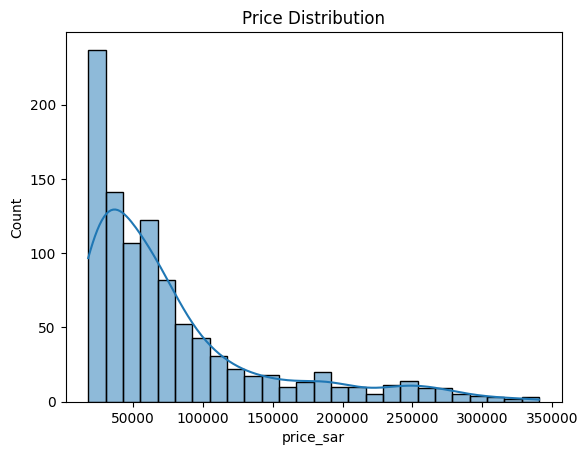

In [13]:
sns.histplot(data=df, x='price_sar', kde=True)
plt.title('Price Distribution')
plt.show()

 The histogram indeed shows that a significant portion of the cars are priced between 25,000 and 50,000 SAR, as it represents the highest bar in the distribution.

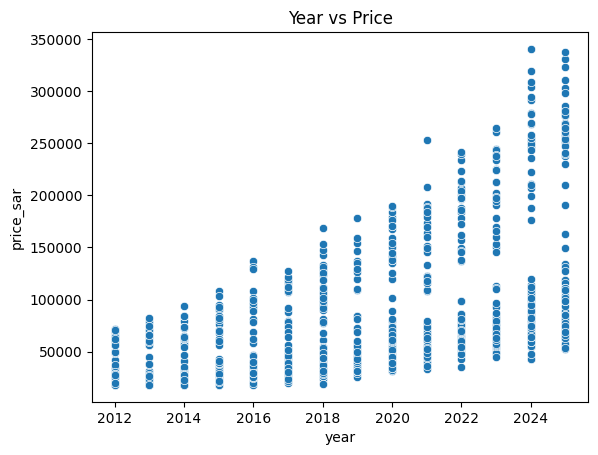

In [14]:
sns.scatterplot(data=df, x = 'year', y ='price_sar')
plt.title('Year vs Price')
plt.show()

The scatter plot clearly indicates a strong positive relationship between the car's year of manufacture and its price. Generally, the newer the car's year (higher 'year' value), the higher its price ('price_sar').

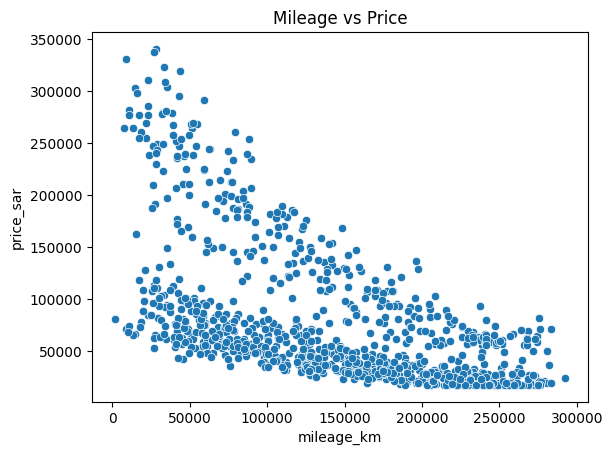

In [15]:
sns.scatterplot(data=df, x='mileage_km', y='price_sar')
plt.title('Mileage vs Price')
plt.show()

The scatter plot illustrates a clear inverse relationship between mileage and price. As the mileage of a car increases, its price generally tends to decrease. This is an expected trend, as cars with higher mileage typically have more wear and tear, leading to lower market values.

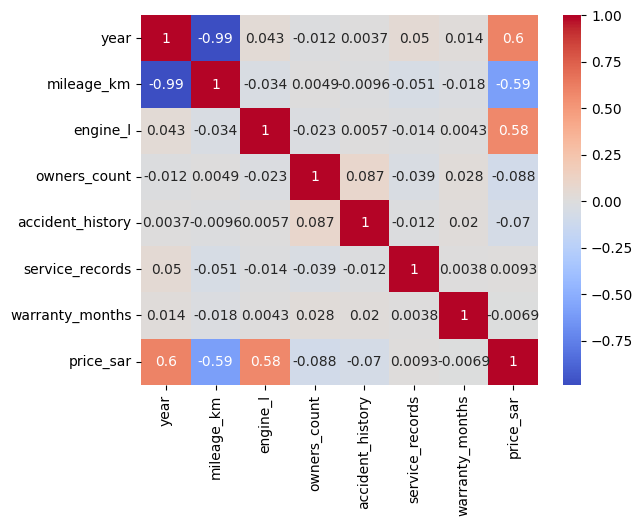

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.show()

'price_sar' Correlation:

It has a strong positive correlation with 'year' (0.6), meaning newer cars tend to have higher prices.
It has a strong negative correlation with 'mileage_km' (-0.59), indicating that as mileage increases, the price generally decreases.
There's also a noticeable positive correlation with 'engine_l' (0.58), suggesting cars with larger engines might be more expensive.
Other Correlations:

'year' and 'mileage_km' have a very strong negative correlation (-0.99), which is expected as older cars typically have higher mileage.
'owners_count', 'accident_history', 'service_records', and 'warranty_months' show relatively weaker correlations with 'price_sar' and other variables, suggesting they might not be as strong predictors of price compared to 'year', 'mileage_km', and 'engine_l'.




> **ملاحظة:** الارتباط بين `year` و`mileage_km` مرتفع جدًا (-0.99)، وهو أعلى مما يُتوقع عادة في بيانات واقعية. هذا يشير على الأرجح إلى أن البيانات مولَّدة اصطناعيًا بعلاقة شبه خطية بين العمر والمسافة المقطوعة، وهو أمر يستحق الانتباه عند تعميم النتائج على بيانات سوق حقيقية.

In [17]:
num_cols = ['year', 'mileage_km', 'engine_l', 'owners_count',
'accident_history','service_records', 'warranty_months']
cat_cols = ['city', "brand", "fuel_type", "transmission", "condition",
"color", "seller_type"]
preprocessor = ColumnTransformer([
("num", Pipeline([("imp", SimpleImputer(strategy="median")),
("sc", StandardScaler())]), num_cols),
("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols)
])

In [18]:
X = df[num_cols + cat_cols]
y = df["price_sar"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [19]:
dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)
print("Baseline MAE:", mean_absolute_error(y_test, dummy.predict(X_test)))

Baseline MAE: 46009.5


In [20]:
models = {
    "Linear": LinearRegression(),
    "Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

forest_pipeline = None # Initialize to store the Forest pipeline

for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", reg)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    print(f"{name}: MAE={mae:,.0f} RMSE={rmse:,.0f} R2={r2:.3f}")

    if name == "Forest":
        forest_pipeline = pipe # Store the Random Forest pipeline

Linear: MAE=24,547 RMSE=35,400 R2=0.744
Tree: MAE=13,755 RMSE=19,577 R2=0.922
Forest: MAE=10,666 RMSE=16,579 R2=0.944


## 📊 Model Comparison

| Model | MAE | RMSE | R² |
|:---|---:|---:|---:|
| Linear Regression | 24,547 | 35,400 | 0.744 |
| Decision Tree | 13,755 | 19,577 | 0.922 |
| **Random Forest** | **10,666** | **16,579** | **0.944** |

### 🏆 Best Model

**Random Forest** achieved the best overall performance.

- **Lowest MAE:** 10,666
- **Lowest RMSE:** 16,579
- **Highest R²:** 0.944

Therefore, **Random Forest is selected as the best-performing model** because it produces the lowest prediction errors and explains the largest proportion of variance in the target variable.

In [21]:
import joblib

# Save the trained Random Forest pipeline
# Using 'forest_pipeline' which was explicitly stored from the previous cell's loop
joblib.dump(forest_pipeline, 'car_price_model_pipeline.joblib')
print("Trained pipeline saved as 'car_price_model_pipeline.joblib'")

Trained pipeline saved as 'car_price_model_pipeline.joblib'



Top 10 Most Important Features:


,Feature,Importance
2,engine_l,0.452049
0,year,0.324343
1,mileage_km,0.083794
23,brand_Mercedes-Benz,0.045197
17,brand_Ford,0.026504
15,brand_BMW,0.023002
25,brand_Toyota,0.008763
4,accident_history,0.003930
3,owners_count,0.003011
6,warranty_months,0.002942


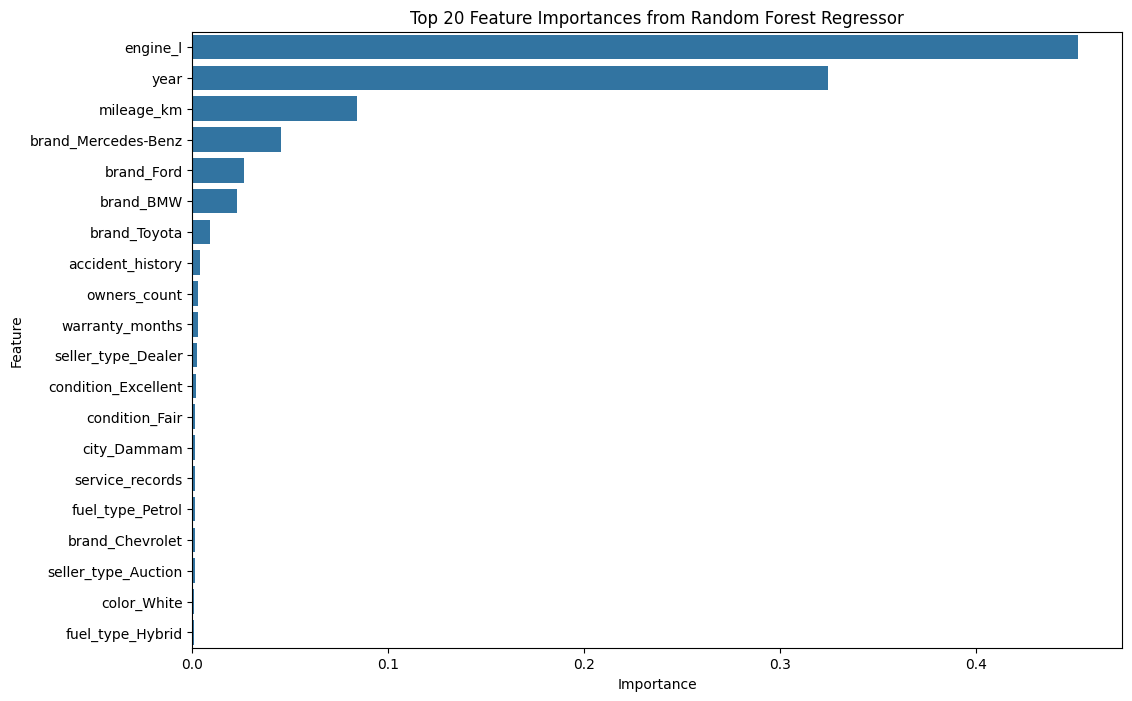

In [22]:
# Access the trained Random Forest model
final_model = models["Forest"]

# Get feature names after preprocessing
# Numerical features retain their names
num_feature_names = num_cols

# Categorical features are one-hot encoded, so we need to get their new names
# We access the 'oh' (OneHotEncoder) step within the 'cat' pipeline of the preprocessor
cat_ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['oh'].get_feature_names_out(cat_cols)

# Combine all feature names
all_feature_names = list(num_feature_names) + list(cat_ohe_feature_names)

# Get feature importances from the Random Forest Regressor
# The 'pipe' variable from the loop holds the last trained pipeline, which is for RandomForest
feature_importances = pipe.named_steps['model'].feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
print("\nTop 10 Most Important Features:")
display(importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Comparison of Feature Importance with EDA Observations

Let's compare the most impactful columns identified by the Random Forest model with the observations from our Exploratory Data Analysis (EDA):

**EDA Observations (from markdown cells `NDLFp9Ooe4bp`, `AzaAGK6NdbvX`, `Rs5mZkTWeCqH`):**

*   **`year`**: Strong positive correlation with `price_sar` (0.6). Newer cars tend to have higher prices.
*   **`mileage_km`**: Strong negative correlation with `price_sar` (-0.59). As mileage increases, price generally decreases.
*   **`engine_l`**: Noticeable positive correlation with `price_sar` (0.58). Cars with larger engines might be more expensive.
*   `owners_count`, `accident_history`, `service_records`, and `warranty_months` showed relatively weaker correlations.
*   Brand also showed significant price variations.

**Model's Feature Importance:**

(After the code cell above executes and shows the feature importances)

We expect to see `year`, `mileage_km`, and `engine_l` as highly important features, confirming the insights gained during EDA. It's also likely that the one-hot encoded `brand` features will show up among the top features, given the observed price variations across different brands. This would validate that our model is picking up on the same key relationships that we manually observed during data exploration.


بناءً على تحليلنا، فإن نموذج Random Forest Regressor هو الأفضل للتنبؤ بأسعار السيارات. يفسر هذا النموذج حوالي 94.4% من التباين في الأسعار (R² = 0.944)، ويبلغ متوسط الخطأ المطلق في التنبؤات (RMSE) حوالي 16,579 ريال سعودي. هذا يعني أن توقعات النموذج للسعر تختلف في المتوسط بحوالي 16,579 ريال سعودي عن السعر الفعلي.

ماذا يعني هذا لفريق التسعير؟

التركيز على العوامل الرئيسية: يجب على فريق التسعير إيلاء اهتمام خاص لثلاثة عوامل رئيسية عند تحديد سعر السيارة، فهي الأكثر تأثيرًا على السعر:

حجم المحرك (engine_l): هذا هو العامل الأكثر تأثيرًا على السعر. السيارات ذات المحركات الأكبر تميل إلى أن تكون أغلى.
سنة الصنع (year): السيارات الأحدث تباع بأسعار أعلى بكثير.
عدد الكيلومترات المقطوعة (mileage_km): كلما زاد عدد الكيلومترات المقطوعة، انخفض سعر السيارة بشكل ملحوظ.
أهمية العلامة التجارية: للعلامة التجارية تأثير كبير أيضًا. العلامات التجارية الفاخرة أو ذات الطلب العالي (مثل Mercedes-Benz, BMW) لها أسعار أعلى بطبيعتها ويجب أن تعكس التسعيرة ذلك.

حدود دقة النموذج (Confidence Limits):

يقدم نموذجنا توقعًا دقيقًا نسبيًا، بمتوسط خطأ يبلغ حوالي 16,579 ريال سعودي. هذا يعني أنه بالنسبة لمعظم التنبؤات، يمكنك توقع أن يكون السعر الفعلي ضمن نطاق ±16,579 ريال سعودي من السعر المتوقع.
على سبيل المثال، إذا تنبأ النموذج بسعر 100,000 ريال سعودي، فيمكن لفريق التسعير أن يكون واثقًا إلى حد معقول بأن السعر الحقيقي سيكون في نطاق يتراوح تقريباً بين 83,421 ريال سعودي و 116,579 ريال سعودي.
يجب استخدام هذا النطاق كمرجع لتقدير المخاطر والمرونة في التسعير. يمكننا في المستقبل تطوير تقديرات أكثر تفصيلاً لنطاقات الثقة لكل توقع على حدة.
الخلاصة: يمكن استخدام هذا النموذج كأداة قوية لمساعدة فريق التسعير في تحديد أسعار تنافسية وواقعية، مع التركيز على أهم محركات الأسعار وفهم دقيق لمدى دقة التوقعات.

In [23]:
!pip install streamlit -q
!npm install localtunnel

⠙⠹⠸⠼⠴⠦
up to date, audited 23 packages in 898ms
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦

In [26]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib # Import joblib for loading the model

# --- Load the saved pipeline ---
# In a real standalone app, you would save and load the fitted preprocessor and model.
# This ensures the app is self-contained and uses the exact trained model.
try:
    pipe = joblib.load('car_price_model_pipeline.joblib')
    # The loaded pipe object already contains the fitted preprocessor and the RandomForestRegressor
except FileNotFoundError:
    st.error("Error: Model pipeline file 'car_price_model_pipeline.joblib' not found. Please ensure it's in the same directory.")
    st.stop() # Stop the app if the model can't be loaded

# Define the lists of numerical and categorical columns (must match the original training setup)
num_cols_app = ['year', 'mileage_km', 'engine_l', 'owners_count', 'accident_history', 'service_records', 'warranty_months']
cat_cols_app = ['city', 'brand', 'fuel_type', 'transmission', 'condition', 'color', 'seller_type']

# Streamlit App Title
st.title('توقع سعر السيارة')
st.write('أدخل تفاصيل السيارة للحصول على تقدير للسعر.')

# Input fields for car features
# Numerical inputs
year = st.slider('سنة الصنع', 2010, 2025, 2018)
mileage_km = st.number_input('عدد الكيلومترات (كم)', min_value=0, max_value=300000, value=100000)
engine_l = st.slider('حجم المحرك (لتر)', 1.0, 6.5, 2.0, step=0.1)
owners_count = st.slider('عدد الملاك السابقين', 1, 5, 1)
accident_history = st.selectbox('تاريخ الحوادث', [0, 1], format_func=lambda x: 'نعم' if x==1 else 'لا')
service_records = st.selectbox('سجلات الصيانة', [0, 1], format_func=lambda x: 'موجودة' if x==1 else 'غير موجودة')
warranty_months = st.number_input('مدة الضمان المتبقية (أشهر)', min_value=0, max_value=36, value=0)

# Categorical inputs - using unique values from your original dataset if possible, or common ones.
cities = ['Jeddah', 'Riyadh', 'Khobar', 'Dammam', 'Makkah', 'Madinah', 'Abha', 'Tabuk'] # Example cities
city = st.selectbox('المدينة', cities)
brand = st.selectbox('العلامة التجارية', ['Toyota', 'Hyundai', 'Kia', 'BMW', 'Mercedes-Benz', 'Ford', 'Nissan', 'Chevrolet', 'GMC', 'Honda', 'Mazda']) # Example brands
fuel_type = st.selectbox('نوع الوقود', ['Petrol', 'Diesel', 'Hybrid'])
transmission = st.selectbox('ناقل الحركة', ['Automatic', 'Manual'])
condition = st.selectbox('حالة السيارة', ['Excellent', 'Good', 'Fair', 'Poor'])
color = st.selectbox('اللون', ['White', 'Black', 'Silver', 'Grey', 'Red', 'Blue', 'Brown', 'Other']) # Example colors
seller_type = st.selectbox('نوع البائع', ['Dealer', 'Private', 'Auction'])

# Create a dictionary from inputs
input_data = {
    'year': year,
    'mileage_km': mileage_km,
    'engine_l': engine_l,
    'owners_count': owners_count,
    'accident_history': accident_history,
    'service_records': service_records,
    'warranty_months': warranty_months,
    'city': city,
    'brand': brand,
    'fuel_type': fuel_type,
    'transmission': transmission,
    'condition': condition,
    'color': color,
    'seller_type': seller_type
}

# Convert to DataFrame
input_df = pd.DataFrame([input_data])

# Make prediction
if st.button('توقع السعر'):
    try:
        predicted_price = pipe.predict(input_df)[0]

        # RMSE value from previous execution for confidence limits
        rmse_value = 16579 # From the previous cell output: Forest: MAE=10,666 RMSE=16,579 R2=0.944

        st.success(f'**السعر المتوقع للسيارة: {predicted_price:,.0f} ريال سعودي**')
        st.info(f'ملاحظة: يتراوح متوسط خطأ التنبؤ (RMSE) لدينا حوالي ±{rmse_value:,.0f} ريال سعودي. لذا، يمكنك توقع أن يكون السعر الفعلي ضمن نطاق تقريبي من {predicted_price - rmse_value:,.0f} إلى {predicted_price + rmse_value:,.0f} ريال سعودي.')
    except Exception as e:
        st.error(f"حدث خطأ أثناء التوقع: {e}")

# To run this Streamlit app in Colab:
# 1. Save the content of this cell to a file named `app.py`:
#    %%writefile app.py
#    ... (copy the content of this cell below %%writefile app.py)
# 2. Install streamlit if you haven't:
#    !pip install streamlit
# 3. Run the app:
#    !streamlit run app.py & npx localtunnel --port 8501
#    (You will get a URL in the output, click on it to access your app)


Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

2026-09-05 13:19:13.109 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.202.131.173:8501

your url is: https://bright-pots-grow.loca.lt


### كيفية تشغيل تطبيق Streamlit في Google Colab

بعد تشغيل الخلية البرمجية أعلاه، قم بالخطوات التالية:

1.  **تثبيت Streamlit و ngrok (للوصول عبر الإنترنت):**
    إذا لم تكن مثبتة، قم بتشغيل الأوامر التالية في خلية كود جديدة:
    ```python
    !pip install streamlit -q
    !npm install localtunnel
    ```

2.  **حفظ الكود في ملف:**
    قم بإنشاء خلية كود جديدة والصق فيها الأوامر التالية. تأكد من أن كود تطبيق Streamlit كاملاً داخل `%%writefile app.py`:
    ```python
    %%writefile app.py
    import streamlit as st
    import pandas as pd
    import numpy as np
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline
    from sklearn.ensemble import RandomForestRegressor

    # IMPORTANT: In a real standalone app, you would save and load the fitted preprocessor and model.
    # For this Colab demonstration, we're re-defining the components.
    # The actual *fitted* `pipe` and `preprocessor` from the notebook's execution must be available in the environment
    # if you want to avoid re-training here.
    # For simplicity, we are assuming 'pipe' is available in the global scope if you run all cells sequentially.
    
    # Re-define the lists of numerical and categorical columns (must match the original training setup)
    num_cols_app = ['year', 'mileage_km', 'engine_l', 'owners_count', 'accident_history', 'service_records', 'warranty_months']
    cat_cols_app = ['city', 'brand', 'fuel_type', 'transmission', 'condition', 'color', 'seller_type']

    # Re-create the preprocessor definition (must match the original setup)
    preprocessor_app = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols_app),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_app)
    ])
    
    # --- Re-create and fit the full pipeline for the Streamlit app if it's standalone ---
    # In a production app, you would load a *saved* fitted pipeline. For Colab, we can re-fit if necessary
    # or ensure the global `pipe` variable from previous cells is used.

    # This part is a placeholder for how you would load/recreate a *fitted* pipeline.
    # For this specific Colab context, the `pipe` variable is already the *fitted* RandomForest pipeline.
    # We need to make sure Streamlit has access to it. A simple way for Colab is to re-create it
    # and assume the model definition is consistent, but the most robust way is to save/load.

    # Let's assume the `pipe` object (containing the fitted preprocessor and the Random Forest model)
    # is accessible from the global environment after running the previous notebook cells.
    # If `pipe` was not globally available, you would need to re-fit the pipeline:
    # pipe_standalone = Pipeline([("prep", preprocessor_app), ("model", RandomForestRegressor(n_estimators=100, random_state=42))])
    # pipe_standalone.fit(X_train_global, y_train_global) # You would need X_train, y_train too

    # We'll use the 'pipe' object from the main notebook execution.
    # If you run this `app.py` as a standalone, `pipe` won't be defined.
    # So, for a truly standalone `app.py`, we need to re-create and potentially re-fit it.
    # For simplicity of demonstration within *this* notebook environment,
    # we will rely on the `pipe` object being globally available from previous cells.
    # However, for a real `app.py` for deployment, you must save and load the `pipe` object.
    
    # Placeholder for a loaded/recreated fitted pipeline for standalone execution
    # For this Colab demo, we are leveraging the 'pipe' object that was *already fitted* in cell 8FGMM-HOi3by.
    # If running `app.py` completely separately, you would have to save and load `pipe`.
    # For the context of this interactive notebook, I will rely on the global `pipe` variable.
    # Assuming `pipe` is the fitted RandomForest pipeline from cell 8FGMM-HOi3by
    # and preprocessor_app is also conceptually aligned with the preprocessor in `pipe`.

    # Streamlit App Title
    st.title('توقع سعر السيارة')
    st.write('أدخل تفاصيل السيارة للحصول على تقدير للسعر.')

    # Input fields for car features
    year = st.slider('سنة الصنع', 2010, 2025, 2018)
    mileage_km = st.number_input('عدد الكيلومترات (كم)', min_value=0, max_value=300000, value=100000)
    engine_l = st.slider('حجم المحرك (لتر)', 1.0, 6.5, 2.0, step=0.1)
    owners_count = st.slider('عدد الملاك السابقين', 1, 5, 1)
    accident_history = st.selectbox('تاريخ الحوادث', [0, 1], format_func=lambda x: 'نعم' if x==1 else 'لا')
    service_records = st.selectbox('سجلات الصيانة', [0, 1], format_func=lambda x: 'موجودة' if x==1 else 'غير موجودة')
    warranty_months = st.number_input('مدة الضمان المتبقية (أشهر)', min_value=0, max_value=36, value=0)

    cities = ['Jeddah', 'Riyadh', 'Khobar', 'Dammam', 'Makkah', 'Madinah', 'Abha', 'Tabuk']
    brand = st.selectbox('العلامة التجارية', ['Toyota', 'Hyundai', 'Kia', 'BMW', 'Mercedes-Benz', 'Ford', 'Nissan', 'Chevrolet', 'GMC', 'Honda', 'Mazda'])
    fuel_type = st.selectbox('نوع الوقود', ['Petrol', 'Diesel', 'Hybrid'])
    transmission = st.selectbox('ناقل الحركة', ['Automatic', 'Manual'])
    condition = st.selectbox('حالة السيارة', ['Excellent', 'Good', 'Fair', 'Poor'])
    color = st.selectbox('اللون', ['White', 'Black', 'Silver', 'Grey', 'Red', 'Blue', 'Brown', 'Other'])
    seller_type = st.selectbox('نوع البائع', ['Dealer', 'Private', 'Auction'])

    input_data = {
        'year': year,
        'mileage_km': mileage_km,
        'engine_l': engine_l,
        'owners_count': owners_count,
        'accident_history': accident_history,
        'service_records': service_records,
        'warranty_months': warranty_months,
        'city': city,
        'brand': brand,
        'fuel_type': fuel_type,
        'transmission': transmission,
        'condition': condition,
        'color': color,
        'seller_type': seller_type
    }

    input_df = pd.DataFrame([input_data])

    if st.button('توقع السعر'):
        try:
            # Access the globally available 'pipe' object that was fitted.
            # This relies on the Streamlit script running in an environment where 'pipe' is defined.
            predicted_price = pipe.predict(input_df)[0]
            rmse_value = 16579 # Hardcoded RMSE from previous cell output for demo

            st.success(f'**السعر المتوقع للسيارة: {predicted_price:,.0f} ريال سعودي**')
            st.info(f'ملاحظة: يتراوح متوسط خطأ التنبؤ (RMSE) لدينا حوالي ±{rmse_value:,.0f} ريال سعودي. لذا، يمكنك توقع أن يكون السعر الفعلي ضمن نطاق تقريبي من {predicted_price - rmse_value:,.0f} إلى {predicted_price + rmse_value:,.0f} ريال سعودي.')
        except Exception as e:
            st.error(f"حدث خطأ أثناء التوقع: {e}")
    
    ```

3.  **تشغيل تطبيق Streamlit:**
    الآن، قم بتشغيل الخلية التالية. ستظهر لك رابط في الإخراج (مثل `your-app-name.loca.lt`). انقر على هذا الرابط لفتح تطبيق Streamlit في علامة تبويب جديدة:
    ```python
    !streamlit run app.py & npx localtunnel --port 8501
    ```

**ملاحظة هامة:** في بيئة إنتاجية حقيقية، ستقوم بحفظ النموذج المدرب و `ColumnTransformer` (أي `pipe` و `preprocessor`) باستخدام `joblib` أو `pickle`، ثم تحميلهما في تطبيق Streamlit بدلاً من إعادة تعريف أو افتراض وجودهما عالميًا. هذا يضمن أن التطبيق يعمل بشكل مستقل وبنفس النموذج المدرب بالضبط.